# Comparing DE methods in delnx

delnx provides several differential expression testing methods, each suited
to different data types and analysis scenarios:

| Method | Function | Data type | Test | Best for |
|--------|----------|-----------|------|----------|
| **ANOVA** | `dx.tl.de(method="anova")` | Log-normalized | F-test | Fast screening, continuous data |
| **Logistic regression** | `dx.tl.de(method="lr")` | Log-normalized / scaled | LR test | Covariate control, classification-style DE |
| **Binomial** | `dx.tl.de(method="binomial")` | Binary (0/1) | LR test | Proportion-based DE on binarized expression |
| **AUROC ranking** | `dx.tl.rank_de()` | Any | Mann-Whitney U | Fast multi-group markers |
| **Negative binomial** | `dx.tl.nb_fit()` + `dx.tl.nb_test()` | Raw counts | Quasi-likelihood F | Pseudobulk, perturbation screens |

This notebook benchmarks their runtime scaling across three axes:
1. **Sample scaling** — how each method scales with increasing cell count
2. **1-vs-all marker detection** — scaling across many groups (clusters)
3. **1-vs-1 pairwise comparisons** — scaling with number of pairwise tests

In [1]:
import time

import anndata as ad
import delnx as dx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
def simulate_data(n_samples, n_genes, n_groups, seed=42):
    """Simulate count data with multiple groups."""
    rng = np.random.default_rng(seed)
    counts = rng.negative_binomial(5, 0.5, size=(n_samples, n_genes)).astype(np.float64)
    adata = ad.AnnData(X=counts)
    adata.var_names = [f"gene_{i}" for i in range(n_genes)]
    adata.obs_names = [f"cell_{i}" for i in range(n_samples)]
    adata.obs["group"] = [f"g{i % n_groups}" for i in range(n_samples)]
    # Log-normalized layer for anova/lr
    adata.layers["counts"] = counts.copy()
    adata.layers["lognorm"] = np.log1p(counts / counts.sum(axis=1, keepdims=True) * 1e4)
    return adata


print("Simulation function defined")

Simulation function defined


In [3]:
# Warm up all JIT caches
a = simulate_data(50, 100, 2)
a_ln = a.copy(); a_ln.X = a_ln.layers["lognorm"]
_ = dx.tl.de(a_ln, condition_key="group", reference="g0", method="anova", verbose=False)
_ = dx.tl.de(a_ln, condition_key="group", reference="g0", method="lr", verbose=False)
_ = dx.tl.rank_de(a, condition_key="group", verbose=False)
fit = dx.tl.nb_fit(a, condition_key="group", reference="g0", verbose=False)
_ = dx.tl.nb_test(a, fit, contrast="group[T.g1]")
print("JIT warmup complete")

JIT warmup complete


## 1. Sample scaling

We vary the number of cells/samples from 100 to 10,000, covering case-control scenarios in (pseudo) bulk and single cell RNA-seq.

Here, the ANOVA and logistic regression methods scale well, while the negative binomial method is much slower due to its iterative fitting procedure.

In [11]:
N_GENES = 10000
sample_sizes = [100, 500, 1000, 2000, 5000, 10000]

sample_results = []

for n in sample_sizes:
    print(f"\n--- {n:,} cells ---")
    adata = simulate_data(n, N_GENES, 2)
    adata_ln = adata.copy()
    adata_ln.X = adata_ln.layers["lognorm"]

    # ANOVA
    t0 = time.time()
    _ = dx.tl.de(adata_ln, condition_key="group", reference="g0", method="anova", verbose=False)
    t = time.time() - t0
    sample_results.append({"n_cells": n, "method": "ANOVA", "time": t})
    print(f"  ANOVA:   {t:.1f}s")

    # LR
    t0 = time.time()
    _ = dx.tl.de(adata_ln, condition_key="group", reference="g0", method="lr", verbose=False)
    t = time.time() - t0
    sample_results.append({"n_cells": n, "method": "LR", "time": t})
    print(f"  LR:      {t:.1f}s")

    # rank_de
    t0 = time.time()
    _ = dx.tl.rank_de(adata, condition_key="group", verbose=False)
    t = time.time() - t0
    sample_results.append({"n_cells": n, "method": "rank_de", "time": t})
    print(f"  rank_de: {t:.1f}s")

    # NB
    t0 = time.time()
    fit = dx.tl.nb_fit(adata, condition_key="group", reference="g0", verbose=False)
    _ = dx.tl.nb_test(adata, fit, contrast="group[T.g1]")
    t = time.time() - t0
    sample_results.append({"n_cells": n, "method": "NB", "time": t})
    print(f"  NB:      {t:.1f}s")

sample_df = pd.DataFrame(sample_results)


--- 100 cells ---
  ANOVA:   0.0s
  LR:      0.0s
  rank_de: 0.7s
  NB:      0.6s

--- 500 cells ---
  ANOVA:   0.1s
  LR:      0.1s
  rank_de: 1.0s
  NB:      1.0s

--- 1,000 cells ---
  ANOVA:   0.1s
  LR:      0.1s
  rank_de: 1.2s
  NB:      1.0s

--- 2,000 cells ---
  ANOVA:   0.2s
  LR:      0.2s
  rank_de: 1.6s
  NB:      2.8s

--- 5,000 cells ---
  ANOVA:   0.3s
  LR:      0.3s
  rank_de: 2.6s
  NB:      2.9s

--- 10,000 cells ---
  ANOVA:   0.5s
  LR:      0.5s
  rank_de: 4.8s
  NB:      5.8s


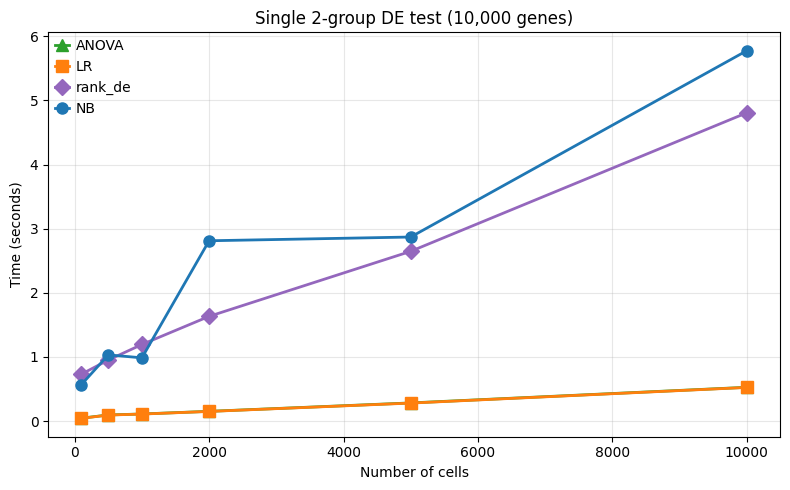

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {"ANOVA": "#2ca02c", "LR": "#ff7f0e", "rank_de": "#9467bd", "NB": "#1f77b4"}
markers = {"ANOVA": "^", "LR": "s", "rank_de": "D", "NB": "o"}

for method in ["ANOVA", "LR", "rank_de", "NB"]:
    sub = sample_df[sample_df["method"] == method].sort_values("n_cells")
    ax.plot(sub["n_cells"], sub["time"], label=method, linewidth=2, markersize=8,
            color=colors[method], marker=markers[method])

ax.set_xlabel("Number of cells")
ax.set_ylabel("Time (seconds)")
ax.set_title(f"Single 2-group DE test ({N_GENES:,} genes)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

## 2. One-vs-all marker detection

Here we vary the number of groups: [5, 10, 20, 50], testing each group against all others. This is a common scenario in single cell RNA-seq, where we want to find markers for each cluster.

`rank_de` scales super well here because it tests all groups in a single pass (vectorized AUROC) while other methods require a loop of independent 1-vs-all tests.

In [15]:
N_CELLS_PER_GROUP = 100
group_counts = [5, 10, 20, 50]

marker_results = []


def run_onevsall_loop(adata, method, use_lognorm=False):
    """Run 1-vs-all DE for each group using a loop."""
    a = adata.copy()
    if use_lognorm:
        a.X = a.layers["lognorm"]
    for g in adata.obs["group"].unique():
        a.obs["is_group"] = (a.obs["group"] == g).astype(str)
        _ = dx.tl.de(a, condition_key="is_group", reference="False", method=method, verbose=False)


def run_onevsall_nb(adata):
    """Run 1-vs-all NB for each group using a loop."""
    for g in adata.obs["group"].unique():
        a = adata.copy()
        a.obs["is_group"] = (a.obs["group"] == g).astype(str)
        fit = dx.tl.nb_fit(a, condition_key="is_group", reference="False", verbose=False)
        _ = dx.tl.nb_test(a, fit, contrast="is_group[T.True]")


for n_groups in group_counts:
    n_total = n_groups * N_CELLS_PER_GROUP
    print(f"\n--- {n_groups} groups, {n_total:,} cells ---")
    adata = simulate_data(n_total, N_GENES, n_groups)

    # rank_de (all groups at once)
    t0 = time.time()
    _ = dx.tl.rank_de(adata, condition_key="group", verbose=False)
    t = time.time() - t0
    marker_results.append({"n_groups": n_groups, "method": "rank_de", "time": t})
    print(f"  rank_de: {t:.1f}s")

    # ANOVA (1-vs-all loop)
    t0 = time.time()
    run_onevsall_loop(adata, "anova", use_lognorm=True)
    t = time.time() - t0
    marker_results.append({"n_groups": n_groups, "method": "ANOVA", "time": t})
    print(f"  ANOVA:   {t:.1f}s")

    # LR (1-vs-all loop)
    t0 = time.time()
    run_onevsall_loop(adata, "lr", use_lognorm=True)
    t = time.time() - t0
    marker_results.append({"n_groups": n_groups, "method": "LR", "time": t})
    print(f"  LR:      {t:.1f}s")

    # NB (1-vs-all loop)
    t0 = time.time()
    run_onevsall_nb(adata)
    t = time.time() - t0
    marker_results.append({"n_groups": n_groups, "method": "NB", "time": t})
    print(f"  NB:      {t:.1f}s")

marker_df = pd.DataFrame(marker_results)


--- 5 groups, 500 cells ---
  rank_de: 1.0s
  ANOVA:   0.5s
  LR:      0.5s
  NB:      5.2s

--- 10 groups, 1,000 cells ---
  rank_de: 1.2s
  ANOVA:   1.1s
  LR:      1.1s
  NB:      10.4s

--- 20 groups, 2,000 cells ---
  rank_de: 1.6s
  ANOVA:   3.3s
  LR:      3.1s
  NB:      56.9s

--- 50 groups, 5,000 cells ---
  rank_de: 2.9s
  ANOVA:   14.2s
  LR:      14.2s
  NB:      150.2s


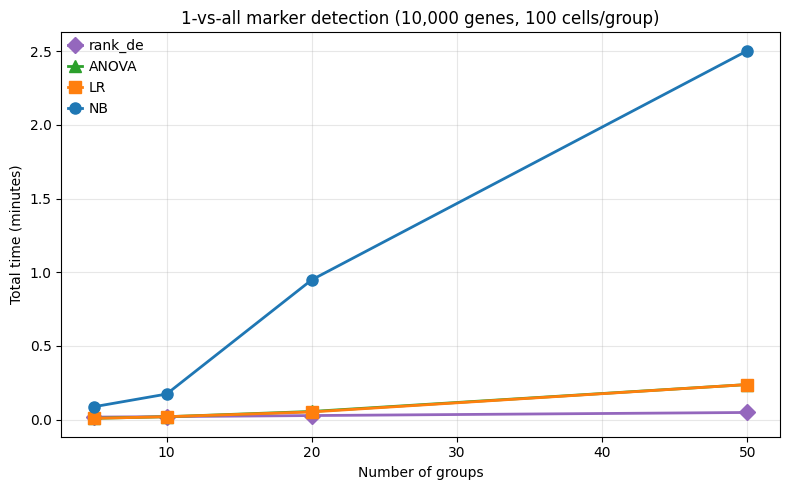

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

for method in ["rank_de", "ANOVA", "LR", "NB"]:
    sub = marker_df[marker_df["method"] == method].sort_values("n_groups")
    ax.plot(sub["n_groups"], sub["time"] / 60, label=method, linewidth=2, markersize=8,
            color=colors[method], marker=markers[method])

ax.set_xlabel("Number of groups")
ax.set_ylabel("Total time (minutes)")
ax.set_title(f"1-vs-all marker detection ({N_GENES:,} genes, {N_CELLS_PER_GROUP} cells/group)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

## 3. NB joint model vs separate fits

For count-based DE with multiple groups, there are two strategies when using the negative binomial method:

- **Joint model**: fit one NB GLM with all groups as coefficients, then test each group via contrasts. Dispersion is estimated from all samples (better for small groups).
- **Separate fits**: fit independent 2-coefficient models (group-vs-rest or group-vs-control). Each fit is fast but dispersion is estimated per subset.

For smaller numers of conditions, the joint fit is much faster since it only requires one model fit, while separate fits require a loop of independent fits. However for more than ~80 conditions, the joint model becomes slower than separate fits, likely due to the increasing complexity of fitting a model with many coefficients and estimating dispersion across many groups.

In [18]:
joint_group_counts = [5, 10, 20, 50, 80, 100]
N_CELLS_PER_TOTAL_JV = 1000

joint_results = []

for n_groups in joint_group_counts:
    print(f"\n--- {n_groups} groups, {N_CELLS_PER_TOTAL_JV:,} cells ---")
    adata = simulate_data(N_CELLS_PER_TOTAL_JV, N_GENES, n_groups)

    # Joint model: fit once with all groups, test each via contrasts
    t0 = time.time()
    fit_joint = dx.tl.nb_fit(adata, condition_key="group", reference="g0", verbose=False)
    contrasts = [c for c in fit_joint.design_column_names if c != "Intercept"]
    for c in contrasts:
        _ = dx.tl.nb_test(adata, fit_joint, contrast=c)
    t_joint = time.time() - t0
    joint_results.append({"n_groups": n_groups, "strategy": "Joint model", "time": t_joint})
    print(f"  Joint ({n_groups} coefs, 1 fit + {len(contrasts)} tests): {t_joint:.1f}s")

    # Separate fits: one 2-coef model per group (1-vs-all)
    t0 = time.time()
    for g in adata.obs["group"].unique():
        a = adata.copy()
        a.obs["is_group"] = (a.obs["group"] == g).astype(str)
        fit_sep = dx.tl.nb_fit(a, condition_key="is_group", reference="False", verbose=False)
        _ = dx.tl.nb_test(a, fit_sep, contrast="is_group[T.True]")
    t_sep = time.time() - t0
    joint_results.append({"n_groups": n_groups, "strategy": "Separate fits", "time": t_sep})
    print(f"  Separate ({n_groups} x 2-coef fits):              {t_sep:.1f}s")
    print(f"  Ratio (joint/separate): {t_joint/t_sep:.2f}x")

joint_df = pd.DataFrame(joint_results)


--- 5 groups, 1,000 cells ---
  Joint (5 coefs, 1 fit + 4 tests): 1.3s
  Separate (5 x 2-coef fits):              5.2s
  Ratio (joint/separate): 0.25x

--- 10 groups, 1,000 cells ---
  Joint (10 coefs, 1 fit + 9 tests): 2.1s
  Separate (10 x 2-coef fits):              10.3s
  Ratio (joint/separate): 0.21x

--- 20 groups, 1,000 cells ---
  Joint (20 coefs, 1 fit + 19 tests): 4.0s
  Separate (20 x 2-coef fits):              20.7s
  Ratio (joint/separate): 0.20x

--- 50 groups, 1,000 cells ---
  Joint (50 coefs, 1 fit + 49 tests): 23.5s
  Separate (50 x 2-coef fits):              51.7s
  Ratio (joint/separate): 0.45x

--- 80 groups, 1,000 cells ---
  Joint (80 coefs, 1 fit + 79 tests): 80.5s
  Separate (80 x 2-coef fits):              83.0s
  Ratio (joint/separate): 0.97x

--- 100 groups, 1,000 cells ---
  Joint (100 coefs, 1 fit + 99 tests): 162.0s
  Separate (100 x 2-coef fits):              103.7s
  Ratio (joint/separate): 1.56x


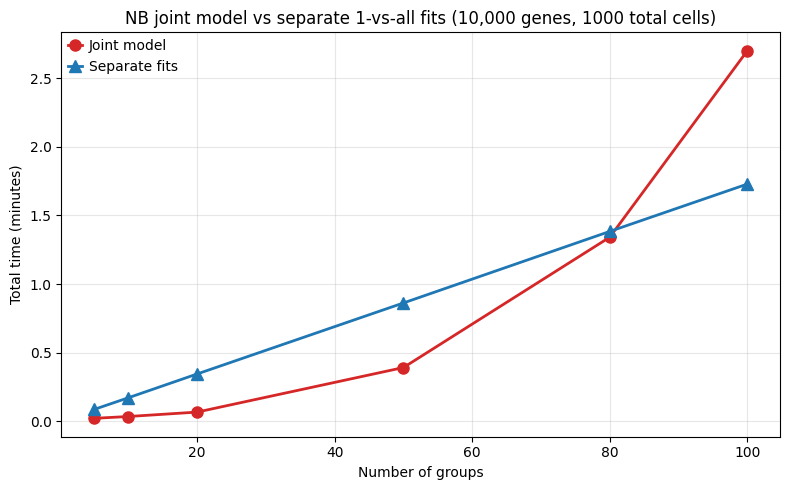

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

for strategy, style in [("Joint model", dict(color="#d62728", marker="o")),
                         ("Separate fits", dict(color="#1f77b4", marker="^"))]:
    sub = joint_df[joint_df["strategy"] == strategy].sort_values("n_groups")
    ax.plot(sub["n_groups"], sub["time"] / 60, label=strategy, linewidth=2, markersize=8, **style)

ax.set_xlabel("Number of groups")
ax.set_ylabel("Total time (minutes)")
ax.set_title(f"NB joint model vs separate 1-vs-all fits ({N_GENES:,} genes, {N_CELLS_PER_TOTAL_JV} total cells)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

## Summary

| Scenario | Recommended method | Why |
|----------|-------------------|-----|
| Quick marker screening | `rank_de` | Tests all groups in one pass, scales to hundreds of clusters |
| Pseudobulk DE (counts) | `nb_fit` + `nb_test` | Proper count model with dispersion shrinkage |
| Lognorm continuous data | `de(method="anova")` | Fast closed-form F-test |
| Covariate control | `de(method="lr")` | Logistic regression with flexible design matrix |
| Binary expression (0/1) | `de(method="binomial")` | Binomial GLM on binarized expression |
| Many pairwise comparisons | `rank_de` or `de(method="anova")` | Low per-test overhead |

**LR vs binomial**: Both use likelihood ratio tests but model different things.
LR predicts the condition label from gene expression (classification-style);
binomial models binary expression as a function of condition (GLM-style).

**Joint vs separate NB models**: Use separate 2-coefficient fits for single-cell data
(many cells per group, fast, parallelizable). Use a joint model for pseudobulk with
few replicates per condition, where pooling dispersions across all samples matters.